[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/seap-udea/MultiNEAs/blob/main/examples/orbit_module_tutorial.ipynb)

# MultiNEAs: Orbit Module Tutorial

## Goal of the module

The **`multineas.orbit2`** module lets you **obtain the orbit of an asteroid** in three ways:

1. **From orbital elements** — You have the Keplerian elements (q, e, i, Ω, ω, M, a) in AU and radians.
2. **From a state vector** — You have position and velocity in Cartesian coordinates (e.g. AU and AU/day).
3. **From impact (fireball) data** — You have the impact site (lon, lat, altitude), impact velocity (Earth-fixed), and time. The module reconstructs the pre-impact heliocentric orbit.

In this notebook we use **Chelyabinsk** impact data as the main example for (3), and we show standalone transformations (state ↔ elements, geodetic ↔ ecliptic), the **Jacobian** of the transformation, and **orbital period**.

## Installation and setup

If you are in Google Colab or need to install the package, run the cell below. Otherwise skip it.

In [19]:
try:
    from google.colab import drive
    %pip install -Uq multineas
except ImportError:
    %load_ext autoreload
    %autoreload 2

# Uncomment to install from GitHub (development version):
# !pip install git+https://github.com/seap-udea/MultiNEAs.git

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Imports and SPICE kernels

Import the orbit module and load SPICE kernels for coordinate transformations (needed for geodetic ↔ ecliptic and impact → orbit).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import warnings
warnings.filterwarnings("ignore")

from multineas.plot import multineas_watermark
from multineas.orbit import (
    Orbit,
    MU_SUN_AU,
    transformation_x_to_e,
    transformation_e_to_x,
    compute_orbital_period,
    compute_jacobian_x_to_e,
    geo_to_rectangular,
    geo_to_eclip,
    get_velocity_ecliptic
)

import spiceypy as spy

path = './data/kernels/'
spy.furnsh([path + 'naif0012.tls', path + 'pck00010.tpc', path + 'earth_fixed.tf', path + 'earth_720101_230601.bpc', path + 'earth_latest_high_prec.bpc'])

---
## 1. Get orbit from orbital elements

Build an `Orbit` from the six classical elements plus semi-major axis: **q** (periapsis distance), **e** (eccentricity), **i** (inclination), **Ω** (longitude of ascending node), **ω** (argument of periapsis), **M** (mean anomaly), **a** (semi-major axis). All lengths in **AU**, angles in **radians**. Use `MU_SUN_AU` for heliocentric orbits.

In [21]:
# Example: elliptical orbit (q, e, i, Omega, w, M, a)
q, e = 0.72, 0.34
i = np.radians(5.0)
Omega = np.radians(100.0)
w = np.radians(30.0)
M = np.radians(0.0)
a = q / (1 - e)

elements = np.array([q, e, i, Omega, w, M])
orbit_from_elements = Orbit(mu=MU_SUN_AU, elements=elements)

print("Orbit from elements:")
print(orbit_from_elements)
print(f"  State vector (AU, AU/day): {orbit_from_elements.state_vector}")
print(f"  Orbital period: {orbit_from_elements.orbital_period:.2f} days")

Orbit from elements:
<Orbit q=0.7200 AU e=0.3400 i=5.00°>
  State vector (AU, AU/day): [-0.46145798  0.55178988  0.03137607 -6.49873131 -5.47140848  0.64305052]
  Orbital period: 1.15 days


In [22]:
q, e, i, Omega, w, M = 1.0, 0.1, 0.2, 0.3, 0.4, 0.5
r, v = transformation_e_to_x(q, e, i, Omega, w, M, MU_SUN_AU)

In [23]:
r

array([0.26970534, 0.9651114 , 0.17074322])

---
## 2. Get orbit from state vector

Build an `Orbit` from position and velocity in Cartesian coordinates: **(x, y, z)** in **AU**, **(vx, vy, vz)** in **AU/day**.

In [24]:
# Example: circular orbit at 1 AU
x, y, z = 1.0, 0.0, 0.0
vx, vy, vz = 0.0, 6.28, 0.0

state_vector = np.array([x, y, z, vx, vy, vz])
orbit_from_state = Orbit(mu=MU_SUN_AU, state_vector=state_vector)

print("Orbit from state vector:")
print(orbit_from_state)
print(f"  Elements (q, e, i, Omega, w, M, a): {orbit_from_state.elements}")
print(f"  Orbital period: {orbit_from_state.orbital_period:.2f} days")

Orbit from state vector:
<Orbit q=1.0000 AU e=0.0112 i=0.00°>
  Elements (q, e, i, Omega, w, M, a): [1.         0.01124103 0.         0.         0.         0.
 1.01136882]
  Orbital period: 1.02 days


---
## 3. Get orbit from impact (fireball) data — Chelyabinsk

Reconstruct the **pre-impact heliocentric orbit** from the impact site (geodetic), impact velocity (Earth-fixed), and time. We use **Chelyabinsk** (2013) as the example.

- **Impact site**: longitude [°], latitude [°], altitude [km]
- **Impact velocity**: vx, vy, vz [km/s] in Earth-fixed frame
- **Date**: UTC string

In [25]:
# Chelyabinsk impact data
impact_site = [60.09285, 55.07815, 178.4583]   # lon [deg], lat [deg], alt [km]
impact_velocity = [12.8, -13.3, -2.4]         # vx, vy, vz [km/s] (Earth-fixed)
impact_date = '2013-02-15 03:20:33'            # UTC

impact_parameters = impact_site + impact_velocity + [impact_date]

orbit_from_impact = Orbit(mu=MU_SUN_AU, impact_parameters=impact_parameters)

el = orbit_from_impact.elements
print("Orbit from Chelyabinsk impact:")
print(orbit_from_impact)
print(f"  q = {el[0]:.6f} AU")
print(f"  e = {el[1]:.6f}")
print(f"  i = {np.degrees(el[2]):.2f}°")
print(f"  Ω = {np.degrees(el[3]):.2f}°")
print(f"  ω = {np.degrees(el[4]):.2f}°")
print(f"  M = {np.degrees(el[5]):.2f}°")
print(f"  a = {el[6]:.6f} AU")
print(f"  Orbital period: {orbit_from_impact.orbital_period:.2f} days ({orbit_from_impact.orbital_period/365.25:.3f} years)")

Orbit from Chelyabinsk impact:
<Orbit q=0.7471 AU e=0.5654 i=4.21°>
  q = 0.747101 AU
  e = 0.565423
  i = 4.21°
  Ω = 326.57°
  ω = 109.07°
  M = 19.68°
  a = 1.719143 AU
  Orbital period: 2.27 days (0.006 years)


---
## 4. Standalone transformations

You can use the same transformation steps **without** the `Orbit` class.

### 4.1 Geodetic → rectangular (Earth-fixed)

`geo_to_rectangular(lon, lat, alt)` returns position [km] in ITRF93.

In [26]:
lon, lat, alt = 60.09285, 55.07815, 178.4583
r_earth_fixed = geo_to_rectangular(lon, lat, alt)
print(f"Earth-fixed position [km]: {r_earth_fixed}")
print(f"Magnitude: {np.linalg.norm(r_earth_fixed):.2f} km")

Earth-fixed position [km]: [1875.53000397 3260.70496115 5352.69238821]
Magnitude: 6542.26 km


### 4.2 Geodetic → ecliptic J2000

`geo_to_eclip(lon, lat, alt, date=date)` returns position [km] in the inertial ecliptic J2000 frame.

In [27]:
r_eclip = geo_to_eclip(lon, lat, alt, date=impact_date)
print(f"Ecliptic J2000 position [km]: {r_eclip}")
print(f"Magnitude: {np.linalg.norm(r_eclip):.2f} km")

Ecliptic J2000 position [km]: [ -943.64333111 -1209.71732415  6359.81498957]
Magnitude: 6542.26 km


### 4.3 Velocity Earth-fixed → ecliptic J2000

`get_velocity_ecliptic(vx, vy, vz, lon, lat, alt, date=date)` converts velocity [km/s] to ecliptic J2000 (accounts for Earth rotation).

In [28]:
vx, vy, vz = impact_velocity
v_eclip = get_velocity_ecliptic(vx, vy, vz, lon, lat, alt, date=impact_date)
print(f"Ecliptic J2000 velocity [km/s]: {v_eclip}")

Ecliptic J2000 velocity [km/s]: [-15.58841921   7.66907281  -5.9183406 ]


### 4.4 State vector ↔ orbital elements

`transformation_x_to_e(x, y, z, vx, vy, vz, mu)` → (q, e, i, Ω, ω, M, a)  
`transformation_e_to_x(q, e, i, Ω, ω, M, mu)` → (x, y, z, vx, vy, vz)  
Units: position [AU], velocity [AU/day], mu [AU³/day²], angles [radians]. Round-trip check:

In [29]:
x, y, z = 1.0, 0.0, 0.0
vx, vy, vz = 0.0, 6.28, 0.0

q, e, i, Omega, w, M, a = transformation_x_to_e(x, y, z, vx, vy, vz, MU_SUN_AU)
r2, v2 = transformation_e_to_x(q, e, i, Omega, w, M, MU_SUN_AU)

pos_err = np.sqrt((r2[0] - x)**2 + (r[1] - y)**2 + (r[2] - z)**2)
vel_err = np.sqrt((v2[0] - vx)**2 + (v2[1] - vy)**2 + (v2[2] - vz)**2)
print(f"Round-trip position error: {pos_err:.2e} AU")
print(f"Round-trip velocity error: {vel_err:.2e} AU/day")

Round-trip position error: 9.80e-01 AU
Round-trip velocity error: 8.88e-16 AU/day


---
## 5. Jacobian matrix

The Jacobian of the map from state vector (x, y, z, vx, vy, vz) to orbital elements (q, e, i, Ω, ω, M) is needed e.g. for transforming probability densities. Use `orbit.jacobian_x_to_e` or the standalone `compute_jacobian_x_to_e(a, e, i, Omega, w, M, mu)`.

In [30]:
# From an existing orbit
J = orbit_from_elements.jacobian_x_to_e
print(f"Jacobian shape: {J.shape}")
print(f"Jacobian determinant: {np.linalg.det(J):.6e}")

# Or standalone (same elements as above)
J2 = compute_jacobian_x_to_e(a, e, i, Omega, w, M, MU_SUN_AU)
print(f"Standalone J determinant: {np.linalg.det(J2):.6e}")

Jacobian shape: (6, 6)
Jacobian determinant: 5.710737e+00
Standalone J determinant: 0.000000e+00


### Jacobian heatmap

Rows: (x, y, z, vx, vy, vz). Columns: (q, e, i, Ω, ω, M).

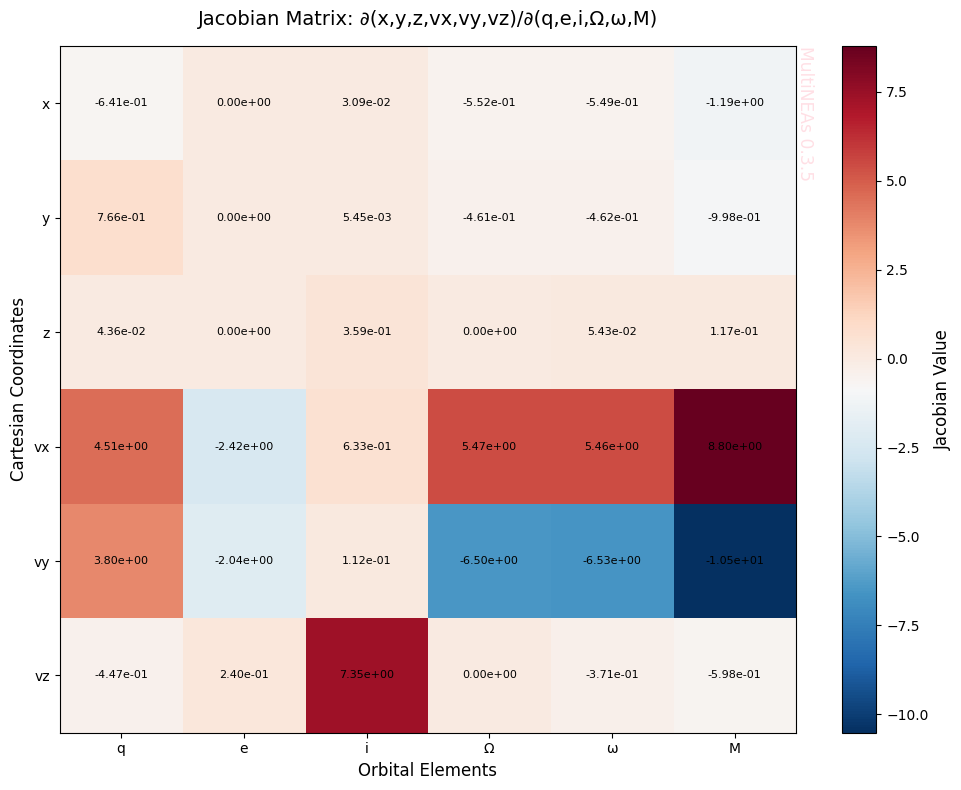

In [31]:
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(J, cmap='RdBu_r', aspect='auto')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Jacobian Value', fontsize=12)

# Set labels
cartesian_labels = ['x', 'y', 'z', 'vx', 'vy', 'vz']
element_labels = ['q', 'e', 'i', 'Ω', 'ω', 'M']

ax.set_xticks(np.arange(len(element_labels)))
ax.set_yticks(np.arange(len(cartesian_labels)))
ax.set_xticklabels(element_labels)
ax.set_yticklabels(cartesian_labels)

ax.set_xlabel('Orbital Elements', fontsize=12)
ax.set_ylabel('Cartesian Coordinates', fontsize=12)
ax.set_title('Jacobian Matrix: ∂(x,y,z,vx,vy,vz)/∂(q,e,i,Ω,ω,M)', fontsize=14, pad=15)
multineas_watermark(ax)

# Add text annotations
for i in range(len(cartesian_labels)):
    for j in range(len(element_labels)):
        text = ax.text(j, i, f'{J[i, j]:.2e}',
                      ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
plt.show()

### Jacobian determinant vs eccentricity

How the absolute value of the Jacobian determinant varies with eccentricity (fixed a = 1 AU, i = 30°). Useful for understanding probability density transformations.

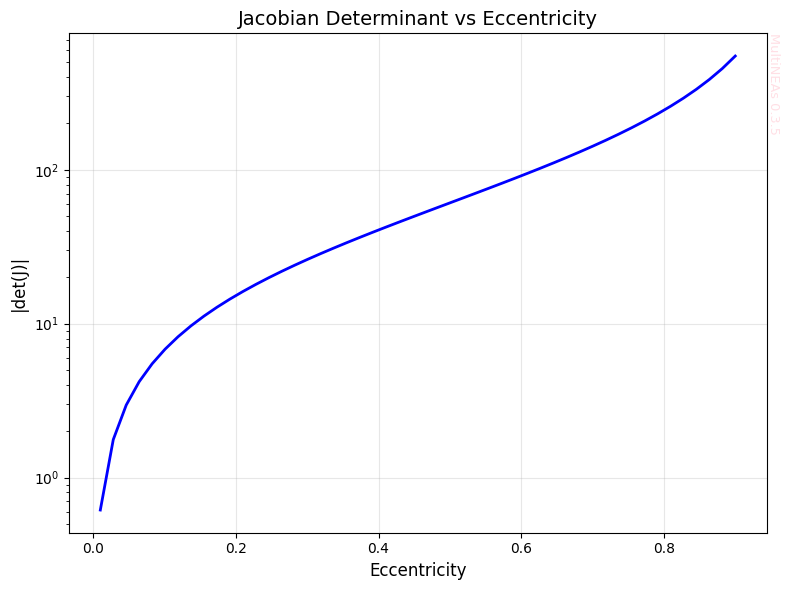

In [32]:
# Study how the Jacobian determinant varies with eccentricity
eccentricities = np.linspace(0.01, 0.9, 50)
determinants = []

a = 1.0  # AU
i = np.pi / 6  # 30 degrees
Omega = 0.0
w = 0.0
M = 0.0

for e in eccentricities:
    try:
        J = compute_jacobian_x_to_e(a, e, i, Omega, w, M, MU_SUN_AU)
        det = np.abs(np.linalg.det(J))
        determinants.append(det)
    except Exception:
        determinants.append(np.nan)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(eccentricities, determinants, 'b-', linewidth=2)
ax.set_xlabel('Eccentricity', fontsize=12)
ax.set_ylabel('|det(J)|', fontsize=12)
ax.set_title('Jacobian Determinant vs Eccentricity', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
multineas_watermark(ax)
plt.tight_layout()
plt.show()

---
## 6. Orbital period

`compute_orbital_period(a, mu)` uses Kepler's third law. Units of `a` and `mu` must match (e.g. AU and AU³/day² → period in days).

---
## 7. Visualize the orbit

Use the `.plot()` method on any `Orbit` instance to draw the orbit in the ecliptic plane (x–y [AU]): Sun at origin, optional Earth circular orbit at 1 AU, and the asteroid orbit with its current position marked.

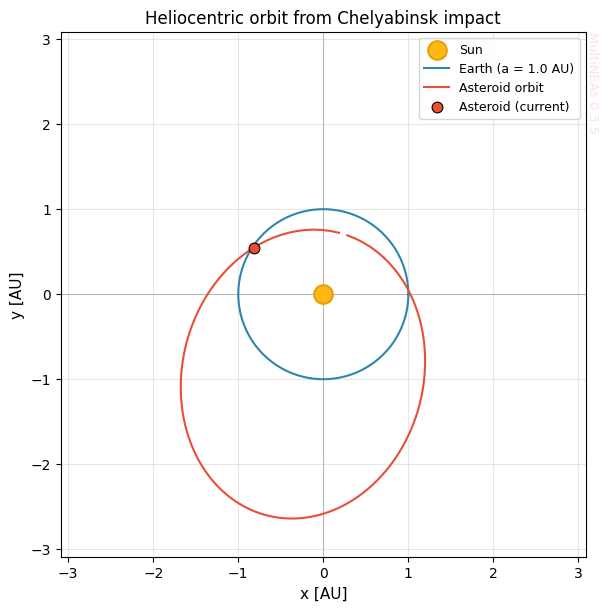

In [33]:
# Plot the Chelyabinsk orbit (from impact parameters)
fig, ax = orbit_from_impact.plot()
ax.set_title("Heliocentric orbit from Chelyabinsk impact")
plt.show()

In [34]:
period_days = compute_orbital_period(1.0, MU_SUN_AU)
period_days

np.float64(1.0061148632539165)

In [35]:
a_earth = 1.0  # AU
period_days = compute_orbital_period(a_earth, MU_SUN_AU)
print(f"Orbital period at a = {a_earth} AU: {period_days:.2f} days ({period_days/365.25:.3f} years)")

# Same as orbit.orbital_period
print(f"From Orbit instance: {orbit_from_state.orbital_period:.2f} days")

Orbital period at a = 1.0 AU: 1.01 days (0.003 years)
From Orbit instance: 1.02 days


### Kepler's third law: orbital period vs semi-major axis

Plot orbital period (days) vs semi-major axis (AU). With `MU_SUN_AU`, `a` in AU gives period in days directly.

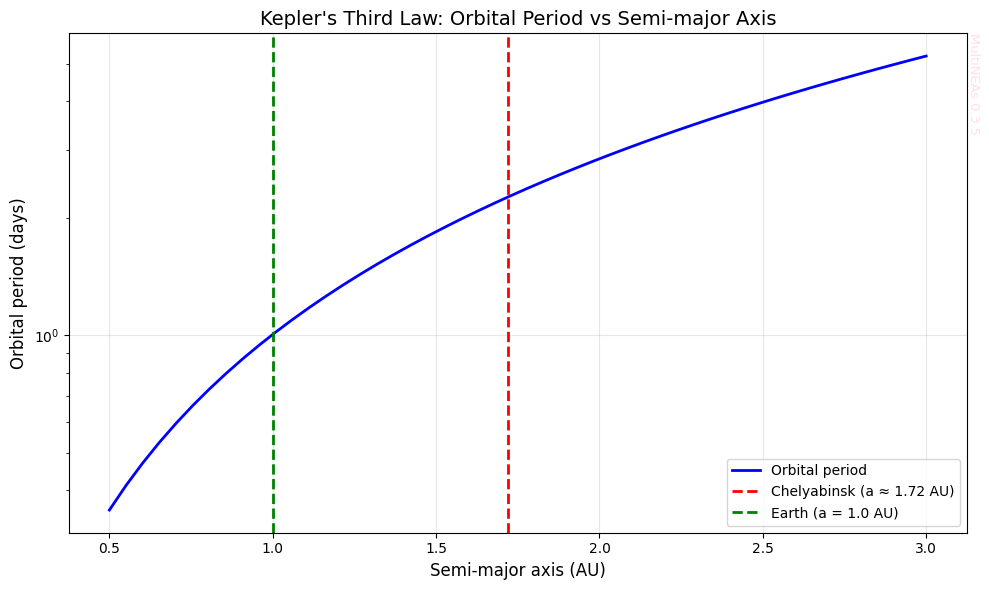

In [36]:
# Create a range of semi-major axes (AU)
a_values_au = np.linspace(0.5, 3.0, 50)
# Period in days (MU_SUN_AU is in AU³/day²)
periods_days = [compute_orbital_period(a, MU_SUN_AU) for a in a_values_au]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(a_values_au, periods_days, 'b-', linewidth=2, label='Orbital period')
a_chelyabinsk = orbit_from_impact.elements[6]
ax.axvline(a_chelyabinsk, color='r', linestyle='--', linewidth=2, label=f'Chelyabinsk (a ≈ {a_chelyabinsk:.2f} AU)')
ax.axvline(1.0, color='g', linestyle='--', linewidth=2, label="Earth (a = 1.0 AU)")

ax.set_xlabel('Semi-major axis (AU)', fontsize=12)
ax.set_ylabel('Orbital period (days)', fontsize=12)
ax.set_title("Kepler's Third Law: Orbital Period vs Semi-major Axis", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

multineas_watermark(ax)
plt.tight_layout()
plt.show()

---
## Summary

| What you have | How to get the orbit |
|---------------|----------------------|
| Orbital elements (q, e, i, Ω, ω, M, a) in AU, rad | `Orbit(mu=MU_SUN_AU, elements=array)` |
| State vector (x,y,z,vx,vy,vz) in AU, AU/day | `Orbit(mu=MU_SUN_AU, state_vector=array)` |
| Impact site + velocity + date (e.g. fireball) | `Orbit(mu=MU_SUN_AU, impact_parameters=[lon,lat,alt,vx,vy,vz,date])` |

**Standalone functions** (same units in/out):
- `geo_to_rectangular`, `geo_to_eclip`, `get_velocity_ecliptic` — geodetic/ecliptic.
- `transformation_x_to_e`, `transformation_e_to_x` — state ↔ elements.
- `compute_jacobian_x_to_e`, `compute_orbital_period`.

**Chelyabinsk** impact data was used to reconstruct the pre-impact heliocentric orbit; the module handles the conversion from Earth-fixed impact coordinates to AU and AU/day internally.